# 🌸 Klasifikasi Jenis Bunga

**Tugas Besar UAS - Kecerdasan Buatan**  
Implementasi Computer Vision untuk Klasifikasi 4 Jenis Bunga

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/My Drive/TB AI Flowers"
DATASET_PATH = f"{BASE_PATH}/dataset"
MODEL_PATH = f"{BASE_PATH}/models/flower_cnn.keras"
TRAIN_PATH = f"{BASE_PATH}/dataset_split/train"
VAL_PATH = f"{BASE_PATH}/dataset_split/validation"

print(f"BASE_PATH: {BASE_PATH}")
print(f"Model akan disimpan di: {MODEL_PATH}")

Mounted at /content/drive
BASE_PATH: /content/drive/My Drive/TB AI Flowers
Model akan disimpan di: /content/drive/My Drive/TB AI Flowers/models/flower_cnn.keras


In [ ]:
!pip install tensorflow streamlit numpy pandas matplotlib seaborn scikit-learn Pillow opencv-python -q

import os, sys, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image as PILImage
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.7 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
CLASS_NAMES = ['matahari', 'mawar', 'melati', 'tulip']
CLASS_LABELS = {name: idx for idx, name in enumerate(CLASS_NAMES)}
CLASS_INDONESIAN = {
    'matahari': 'Bunga Matahari',
    'mawar': 'Bunga Mawar',
    'melati': 'Bunga Melati',
    'tulip': 'Bunga Tulip'
}
VAL_SPLIT = 0.2
RANDOM_SEED = 42
EPOCHS = 50

print("Konfigurasi siap.")
print(f"Kelas: {CLASS_NAMES}")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Konfigurasi siap.
Kelas: ['matahari', 'mawar', 'melati', 'tulip']
Image size: (150, 150)
Batch size: 32
Epochs: 50


In [ ]:
def split_dataset():
    if os.path.exists(TRAIN_PATH):
        print("Dataset already split, skipping.")
        return

    for class_name in CLASS_NAMES:
        class_path = os.path.join(DATASET_PATH, class_name)
        if not os.path.exists(class_path):
            print(f"Warning: {class_path} not found, skipping.")
            continue

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        train_imgs, val_imgs = train_test_split(
            images, test_size=VAL_SPLIT, random_state=RANDOM_SEED
        )

        train_class_dir = os.path.join(TRAIN_PATH, class_name)
        val_class_dir = os.path.join(VAL_PATH, class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        for img in train_imgs:
            shutil.copy2(os.path.join(class_path, img), os.path.join(train_class_dir, img))
        for img in val_imgs:
            shutil.copy2(os.path.join(class_path, img), os.path.join(val_class_dir, img))

    print('Dataset split complete.')
    for class_name in CLASS_NAMES:
        train_count = len(os.listdir(os.path.join(TRAIN_PATH, class_name)))
        val_count = len(os.listdir(os.path.join(VAL_PATH, class_name)))
        print(f'  {class_name}: {train_count} train, {val_count} val')

In [ ]:
def get_data_generators():
    split_dataset()

    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=RANDOM_SEED
    )

    val_generator = val_datagen.flow_from_directory(
        VAL_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        seed=RANDOM_SEED
    )

    return train_generator, val_generator

In [ ]:
def visualize_samples(num_samples=12):
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()

    sample_count = 0
    for class_name in CLASS_NAMES:
        class_path = os.path.join(DATASET_PATH, class_name)
        if not os.path.exists(class_path):
            continue
        img_files = sorted([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for i in range(min(num_samples // len(CLASS_NAMES), len(img_files))):
            if sample_count >= num_samples:
                break
            img_path = os.path.join(class_path, img_files[i])
            img = load_img(img_path, target_size=IMG_SIZE)
            axes[sample_count].imshow(img)
            axes[sample_count].set_title(class_name.title(), fontsize=12, pad=8)
            axes[sample_count].axis('off')
            sample_count += 1

    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/dataset_samples.png", dpi=150)
    plt.show()

Dataset already split, skipping.
Found 313 images belonging to 4 classes.
Found 80 images belonging to 4 classes.
Training samples: 313
Validation samples: 80
Class mapping: {'matahari': 0, 'mawar': 1, 'melati': 2, 'tulip': 3}


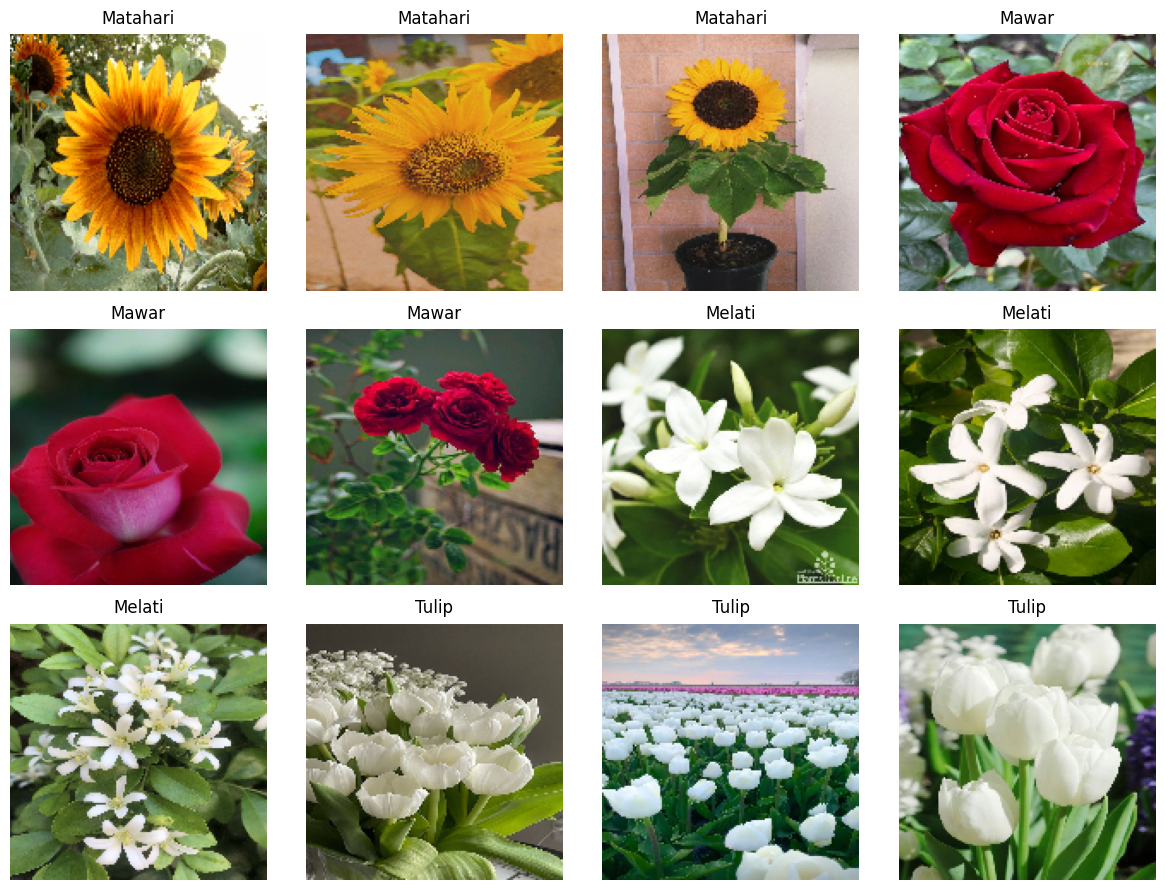

In [ ]:
train_generator, val_generator = get_data_generators()
print(f'Training samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Class mapping: {train_generator.class_indices}')

visualize_samples()

In [ ]:
def build_transfer_learning_model(num_classes=4):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def get_callbacks():
    checkpoint = ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    return [checkpoint, early_stop, reduce_lr]

## Cell 6: Training Model

In [ ]:
model = build_transfer_learning_model(num_classes=len(CLASS_NAMES))
model.summary()

/tmp/ipykernel_502/87230386.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,100 (9.26 MB)

 Trainable params: 167,300 (653.52 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [ ]:
callbacks = get_callbacks()

steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size
if train_generator.samples % train_generator.batch_size != 0:
    steps_per_epoch += 1
if val_generator.samples % val_generator.batch_size != 0:
    validation_steps += 1

print(f'Steps per epoch: {steps_per_epoch}')
print(f'Validation steps: {validation_steps}')
print(f'Starting training for {EPOCHS} epochs...')

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Steps per epoch: 10
Validation steps: 3
Starting training for 50 epochs...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5398 - loss: 1.4495  
Epoch 1: val_accuracy improved from None to 0.95000, saving model to /content/drive/My Drive/TB AI Flowers/models/flower_cnn.keras

Epoch 1: finished saving model to /content/drive/My Drive/TB AI Flowers/models/flower_cnn.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 174s 15s/step - accuracy: 0.6869 - loss: 1.0139 - val_accuracy: 0.9500 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - accuracy: 0.8988 - loss: 0.5215
Epoch 2: val_accuracy improved from 0.95000 to 0.97500, saving model to /content/drive/My Drive/TB AI Flowers/models/flower_cnn.keras

Epoch 2: finished saving model to /content/drive/My Drive/TB AI Flowers/models/flower_cnn.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9105 - loss: 0.4937 - val_accuracy: 0.9750 - val_loss: 0.3300 - learning_rate: 0.0010
Epoch 3/50
10/1

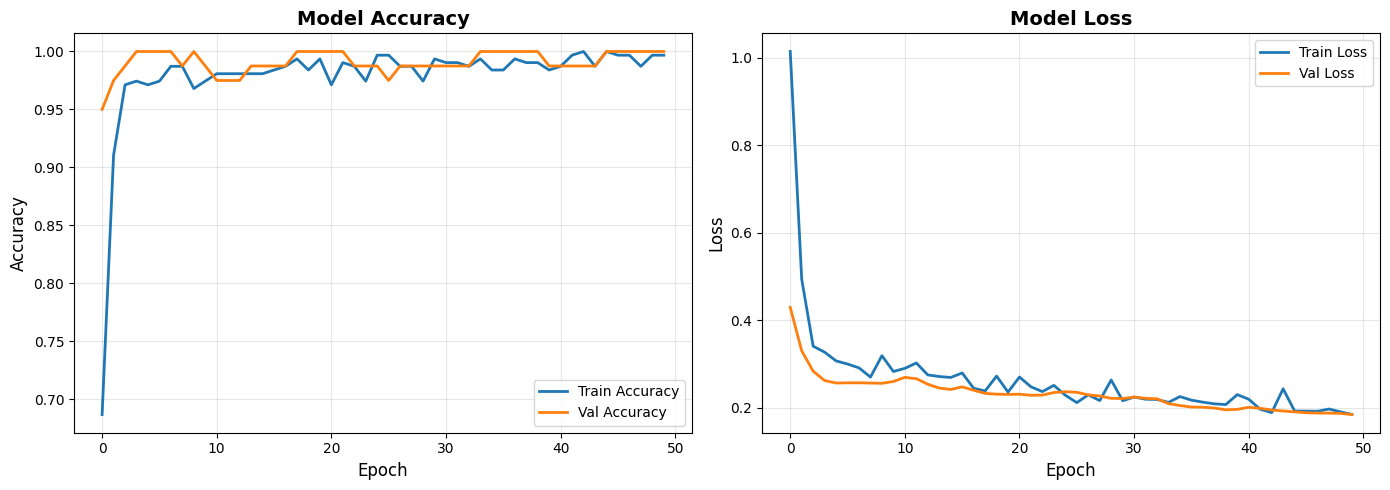


Training Complete!
Best epoch: 4
Best Validation Accuracy: 1.0000
Best Validation Loss: 0.2620
Model saved to: /content/drive/My Drive/TB AI Flowers/models/flower_cnn.keras


In [ ]:
import numpy as np
np.save(f"{BASE_PATH}/models/training_history.npy", history.history)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/training_history.png", dpi=150)
plt.show()

best_epoch = int(np.argmax(history.history['val_accuracy']))
final_val_acc = history.history['val_accuracy'][best_epoch]
final_val_loss = history.history['val_loss'][best_epoch]

print(f'\nTraining Complete!')
print(f'Best epoch: {best_epoch + 1}')
print(f'Best Validation Accuracy: {final_val_acc:.4f}')
print(f'Best Validation Loss: {final_val_loss:.4f}')
print(f'Model saved to: {MODEL_PATH}')

## Cell 7: Evaluasi Model

Confusion Matrix, Classification Report, dan Akurasi per Kelas

In [ ]:
print('Loading model...')
model = load_model(MODEL_PATH)

_, val_generator = get_data_generators()
print(f'Validation samples: {val_generator.samples}')

print('Evaluating on validation data...')
loss, accuracy_val = model.evaluate(val_generator, verbose=1)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy_val:.4f}')

print('Generating predictions...')
val_generator.reset()
steps = val_generator.samples // val_generator.batch_size
if val_generator.samples % val_generator.batch_size != 0:
    steps += 1
predictions = model.predict(val_generator, steps=steps, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes[:len(y_pred)]

print('\nClassification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Loading model...
Dataset already split, skipping.
Found 313 images belonging to 4 classes.
Found 80 images belonging to 4 classes.
Validation samples: 80
Evaluating on validation data...
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 1.0000 - loss: 0.2620
Test Loss: 0.2620
Test Accuracy: 1.0000
Generating predictions...
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step

Classification Report:
              precision    recall  f1-score   support

    matahari       1.00      1.00      1.00        20
       mawar       1.00      1.00      1.00        20
      melati       1.00      1.00      1.00        20
       tulip       1.00      1.00      1.00        20

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



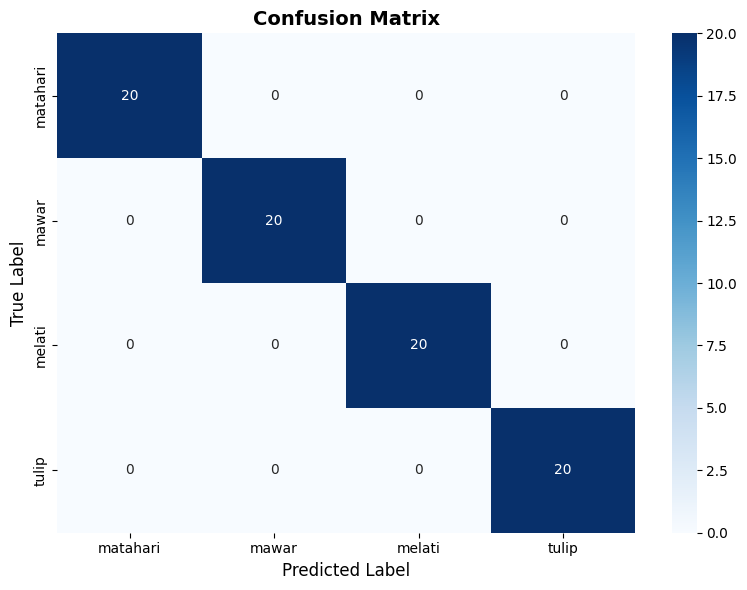

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
print('\nAccuracy per class:')
for i, class_name in enumerate(CLASS_NAMES):
    mask = y_true == i
    if np.sum(mask) > 0:
        class_acc = accuracy_score(y_true[mask], y_pred[mask])
        print(f'  {CLASS_INDONESIAN[class_name]:20s}: {class_acc:.4f}')


Accuracy per class:
  Bunga Matahari      : 1.0000
  Bunga Mawar         : 1.0000
  Bunga Melati        : 1.0000
  Bunga Tulip         : 1.0000


## Cell 8: Demo Prediksi

Upload gambar bunga dan lihat hasil klasifikasinya!

Saving 1.jpg to 1.jpg


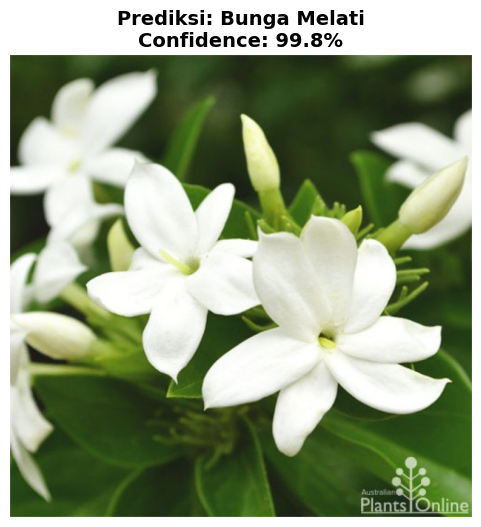


Hasil Prediksi: Bunga Melati
Tingkat Keyakinan: 99.8%

Confidence per class:
  Bunga Matahari      : 0.0005 
  Bunga Mawar         : 0.0009 
  Bunga Melati        : 0.9977 #################################################
  Bunga Tulip         : 0.0009 


In [ ]:
from google.colab import files

model = load_model(MODEL_PATH)

def predict_image(image_path):
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class_idx = int(np.argmax(predictions))
    confidence = float(predictions[predicted_class_idx])
    predicted_class = CLASS_NAMES[predicted_class_idx]
    predicted_name = CLASS_INDONESIAN[predicted_class]

    confidence_per_class = {
        CLASS_INDONESIAN[name]: float(conf)
        for name, conf in zip(CLASS_NAMES, predictions)
    }

    return predicted_name, confidence, confidence_per_class

uploaded = files.upload()

for filename in uploaded.keys():
    predicted_name, confidence, confidence_per_class = predict_image(filename)

    img = PILImage.open(filename)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediksi: {predicted_name}\nConfidence: {confidence*100:.1f}%",
              fontsize=14, fontweight='bold')
    plt.show()

    print(f"\nHasil Prediksi: {predicted_name}")
    print(f"Tingkat Keyakinan: {confidence*100:.1f}%\n")
    print("Confidence per class:")
    for name, conf in confidence_per_class.items():
        bar = '#' * int(conf * 50)
        print(f"  {name:20s}: {conf:.4f} {bar}")